# Análise Exploratória dos Dados

Este notebook apresenta a caracterização inicial das bases utilizadas no projeto, compostas por dados do Censo Escolar e do Índice de Desenvolvimento da Educação Básica (IDEB).

A análise contempla:
- inspeção inicial dos arquivos;
- dimensão das bases;
- cobertura temporal;
- distribuição geográfica;
- valores ausentes;
- duplicidades;
- análise de valores especiais;
- estatísticas descritivas;
- distribuição do IDEB;
- cruzamento entre Censo Escolar e IDEB;
- avaliação da qualidade da integração entre as fontes.


## 1. Importação das bibliotecas


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 2. Inspeção inicial de 1.000 registros

Inicialmente são carregadas apenas as primeiras 1.000 linhas de cada arquivo para verificar sua estrutura, tipos de dados e possíveis problemas iniciais.

Essa amostra é utilizada apenas para inspeção técnica, pois os arquivos não estão necessariamente ordenados de maneira aleatória.


In [ ]:
censo_amostra = pd.read_csv(
    "../data/censo_educacional_nordeste.csv",
    nrows=1000,
    low_memory=False
)

ideb_amostra = pd.read_csv(
    "../data/ideb_nordeste_sem_nulos.csv    ",
    nrows=1000,
    low_memory=False
)

print("Censo Escolar - amostra:", censo_amostra.shape)
print("IDEB - amostra:", ideb_amostra.shape)


Censo Escolar - amostra: (1000, 50)
IDEB - amostra: (1000, 14)


In [3]:
censo_amostra.head()


,ano,sigla_uf,id_municipio,id_municipio_nome,id_escola,rede,tipo_localizacao,tipo_situacao_funcionamento,agua_potavel,agua_rede_publica,energia_rede_publica,esgoto_rede_publica,lixo_servico_coleta,area_verde,banheiro_chuveiro,biblioteca,cozinha,dormitorio_aluno,laboratorio_ciencias,laboratorio_informatica,laboratorio_educacao_profissional,quadra_esportes,refeitorio,sala_leitura,quantidade_sala_utilizada_climatizada,desktop_aluno,internet_alunos,quantidade_profissional_saude,quantidade_profissional_nutricionista,quantidade_profissional_psicologo,quantidade_profissional_pedagogia,profissional_assistente_social,alimentacao,material_pedagogico_multimidia,material_pedagogico_infantil,material_pedagogico_cientifico,material_pedagogico_musical,material_pedagogico_artistica,orgao_gremio_estudantil,diurno,noturno,quantidade_matricula_feminino,quantidade_matricula_masculino,quantidade_matricula_nao_declarada,quantidade_matricula_branca,quantidade_matricula_preta,quantidade_matricula_parda,quantidade_matricula_amarela,quantidade_matricula_indigena,quantidade_matricula_utiliza_transporte_publico
0,2010,AL,2700300,Arapiraca,27224740,Privada,Urbana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010,AL,2700805,Belém,27011836,Municipal,Rural,NaN,NaN,0.00,1.00,0.00,0.00,NaN,NaN,0,1,NaN,0,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,11.00,22.00,21.00,7.00,0.00,5.00,0.00,0.00,NaN
2,2010,AL,2701100,Branquinha,27026523,Municipal,Rural,NaN,NaN,0.00,1.00,0.00,0.00,NaN,NaN,0,0,NaN,0,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,6.00,12.00,4.00,0.00,1.00,13.00,0.00,0.00,NaN
3,2010,AL,2701308,Cajueiro,27219950,Municipal,Rural,NaN,NaN,1.00,1.00,0.00,1.00,NaN,NaN,0,1,NaN,0,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,19.00,48.00,37.00,7.00,0.00,23.00,0.00,0.00,NaN
4,2010,AL,2701506,Campo Grande,27017567,Municipal,Rural,NaN,NaN,1.00,1.00,0.00,0.00,NaN,NaN,0,1,NaN,0,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,1.00,15.00,16.00,27.00,0.00,0.00,4.00,0.00,0.00,NaN


In [4]:
ideb_amostra.head()


,ano,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,id_escola,id_escola_nome,ensino,anos_escolares,taxa_aprovacao,indicador_rendimento,nota_saeb_media_padronizada,ideb,projecao
0,2013,BA,Bahia,2927408,Salvador,29404444,ESCOLA MUNICIPAL 22 DE ABRIL,fundamental,iniciais (1-5),78.50,0.10,4.03,0.40,3.90
1,2005,RN,Rio Grande do Norte,2406502,Lagoa Nova,24078603,EM ADALGISA AMORIM BEZERRA,fundamental,iniciais (1-5),42.50,0.21,2.98,0.60,NaN
2,2009,PB,Paraíba,2507507,João Pessoa,25097091,EEEFM AUDIOCOMUNICACAO,fundamental,iniciais (1-5),14.20,0.14,4.48,0.60,3.40
3,2007,BA,Bahia,2903904,Bom Jesus da Lapa,29043077,ESCOLA MUNICIPALIZADA VITALINA MARIA DE JESUS,fundamental,iniciais (1-5),16.50,0.14,4.05,0.60,NaN
4,2005,PI,Piauí,2202208,Campo Maior,22032339,CETI RAIMUNDINHO ANDRADE,fundamental,finais (6-9),41.40,0.16,4.57,0.70,NaN


## 3. Estrutura das bases


In [5]:
print("Colunas do Censo Escolar:")
print(censo_amostra.columns.tolist())

print("\nColunas do IDEB:")
print(ideb_amostra.columns.tolist())


Colunas do Censo Escolar:
['ano', 'sigla_uf', 'id_municipio', 'id_municipio_nome', 'id_escola', 'rede', 'tipo_localizacao', 'tipo_situacao_funcionamento', 'agua_potavel', 'agua_rede_publica', 'energia_rede_publica', 'esgoto_rede_publica', 'lixo_servico_coleta', 'area_verde', 'banheiro_chuveiro', 'biblioteca', 'cozinha', 'dormitorio_aluno', 'laboratorio_ciencias', 'laboratorio_informatica', 'laboratorio_educacao_profissional', 'quadra_esportes', 'refeitorio', 'sala_leitura', 'quantidade_sala_utilizada_climatizada', 'desktop_aluno', 'internet_alunos', 'quantidade_profissional_saude', 'quantidade_profissional_nutricionista', 'quantidade_profissional_psicologo', 'quantidade_profissional_pedagogia', 'profissional_assistente_social', 'alimentacao', 'material_pedagogico_multimidia', 'material_pedagogico_infantil', 'material_pedagogico_cientifico', 'material_pedagogico_musical', 'material_pedagogico_artistica', 'orgao_gremio_estudantil', 'diurno', 'noturno', 'quantidade_matricula_feminino', 'q

In [6]:
print("Tipos de dados - Censo Escolar")
display(censo_amostra.dtypes.to_frame("tipo"))

print("\nTipos de dados - IDEB")
display(ideb_amostra.dtypes.to_frame("tipo"))


Tipos de dados - Censo Escolar


,tipo
ano,int64
sigla_uf,str
id_municipio,int64
id_municipio_nome,str
id_escola,int64
rede,str
tipo_localizacao,str
tipo_situacao_funcionamento,float64
agua_potavel,float64
agua_rede_publica,float64



Tipos de dados - IDEB


,tipo
ano,int64
sigla_uf,str
sigla_uf_nome,str
id_municipio,int64
id_municipio_nome,str
id_escola,int64
id_escola_nome,str
ensino,str
anos_escolares,str
taxa_aprovacao,float64


## 4. Carregamento completo das bases


In [7]:
censo = pd.read_csv(
    "../data/censo_educacional_nordeste.csv",
    low_memory=False
)

ideb = pd.read_csv(
    "../data/ideb_nordeste_sem_nulos.csv",
    low_memory=False
)

print(f"Censo Escolar: {censo.shape[0]:,} registros e {censo.shape[1]} colunas")
print(f"IDEB: {ideb.shape[0]:,} registros e {ideb.shape[1]} colunas")


Censo Escolar: 1,557,932 registros e 50 colunas
IDEB: 54,997 registros e 14 colunas


## 5. Cobertura temporal


In [8]:
anos_censo = sorted(censo["ano"].dropna().unique())
anos_ideb = sorted(ideb["ano"].dropna().unique())

print("Anos disponíveis no Censo:")
print(anos_censo)

print("\nAnos disponíveis no IDEB:")
print(anos_ideb)


Anos disponíveis no Censo:
[np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Anos disponíveis no IDEB:
[np.int64(2005), np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021), np.int64(2023), np.int64(2025)]


In [9]:
distribuicao_censo_ano = (
    censo["ano"]
    .value_counts()
    .sort_index()
    .rename_axis("ano")
    .reset_index(name="registros")
)

display(distribuicao_censo_ano)


,ano,registros
0,2007,80912
1,2008,84100
2,2009,82049
3,2010,80209
4,2011,97328
5,2012,96807
6,2013,95855
7,2014,95423
8,2015,91659
9,2016,92260


In [10]:
distribuicao_ideb_ano = (
    ideb["ano"]
    .value_counts()
    .sort_index()
    .rename_axis("ano")
    .reset_index(name="registros")
)

display(distribuicao_ideb_ano)


,ano,registros
0,2005,3778
1,2007,4243
2,2009,5487
3,2011,5035
4,2013,4736
5,2015,4531
6,2017,5403
7,2019,5718
8,2021,4370
9,2023,5711


### 5.1 Distribuição do Censo por faixas



In [12]:
faixas = {
    "2007–2012": (2007, 2012),
    "2013–2018": (2013, 2018),
    "2019–2024": (2019, 2024)
}

resultado_faixas = []

for nome, (inicio, fim) in faixas.items():
    total = censo[censo["ano"].between(inicio, fim)].shape[0]
    resultado_faixas.append({
        "faixa_temporal": nome,
        "total_registros": total
    })

faixas_df = pd.DataFrame(resultado_faixas)
display(faixas_df)


,faixa_temporal,total_registros
0,2007–2012,521405
1,2013–2018,558486
2,2019–2024,478041


## 6. Distribuição geográfica


In [ ]:
censo_por_estado = (
    censo["sigla_uf"]
    .value_counts()
    .rename_axis("UF")
    .reset_index(name="registros")
)

display(censo_por_estado)


In [ ]:
ideb_por_estado = (
    ideb["sigla_uf"]
    .value_counts()
    .rename_axis("UF")
    .reset_index(name="registros")
)

display(ideb_por_estado)


## 7. Dependência administrativa e localização


In [13]:
rede = (
    censo["rede"]
    .value_counts(dropna=False)
    .rename_axis("rede")
    .reset_index(name="registros")
)

display(rede)


,rede,registros
0,Municipal,1171722
1,Privada,242138
2,Estadual,140710
3,Federal,3362


In [14]:
localizacao = (
    censo["tipo_localizacao"]
    .value_counts(dropna=False)
    .rename_axis("tipo_localizacao")
    .reset_index(name="registros")
)

display(localizacao)


,tipo_localizacao,registros
0,Rural,884289
1,Urbana,673643


## 8. Valores ausentes no Censo Escolar


In [15]:
nulos_censo = pd.DataFrame({
    "quantidade_nulos": censo.isna().sum(),
    "percentual_nulos": censo.isna().mean() * 100
}).sort_values("percentual_nulos", ascending=False)

display(nulos_censo)


,quantidade_nulos,percentual_nulos
tipo_situacao_funcionamento,1557932,100.00
quantidade_matricula_utiliza_transporte_publico,1438188,92.31
laboratorio_educacao_profissional,1376464,88.35
profissional_assistente_social,1253449,80.46
quantidade_profissional_psicologo,1190602,76.42
material_pedagogico_cientifico,1190602,76.42
orgao_gremio_estudantil,1190602,76.42
material_pedagogico_infantil,1190602,76.42
material_pedagogico_musical,1190602,76.42
material_pedagogico_multimidia,1190602,76.42


## 9. Valores ausentes no IDEB


In [16]:
nulos_ideb = pd.DataFrame({
    "quantidade_nulos": ideb.isna().sum(),
    "percentual_nulos": ideb.isna().mean() * 100
}).sort_values("percentual_nulos", ascending=False)

display(nulos_ideb)


,quantidade_nulos,percentual_nulos
projecao,22103,40.19
id_escola_nome,987,1.79
sigla_uf_nome,0,0.00
id_municipio,0,0.00
ano,0,0.00
sigla_uf,0,0.00
id_escola,0,0.00
id_municipio_nome,0,0.00
anos_escolares,0,0.00
ensino,0,0.00


## 10. Disponibilidade temporal das variáveis


In [17]:
disponibilidade = []

for coluna in censo.columns:
    registros_validos = censo.loc[censo[coluna].notna(), ["ano", coluna]]

    if not registros_validos.empty:
        primeiro_ano = registros_validos["ano"].min()
        ultimo_ano = registros_validos["ano"].max()
    else:
        primeiro_ano = np.nan
        ultimo_ano = np.nan

    disponibilidade.append({
        "variavel": coluna,
        "primeiro_ano_com_dado": primeiro_ano,
        "ultimo_ano_com_dado": ultimo_ano
    })

disponibilidade_df = pd.DataFrame(disponibilidade)
display(disponibilidade_df)


,variavel,primeiro_ano_com_dado,ultimo_ano_com_dado
0,ano,ano 2007 ano 2007 dtype: int64,ano 2024 ano 2024 dtype: int64
1,sigla_uf,2007,2024
2,id_municipio,2007,2024
3,id_municipio_nome,2007,2024
4,id_escola,2007,2024
5,rede,2007,2024
6,tipo_localizacao,2007,2024
7,tipo_situacao_funcionamento,NaN,NaN
8,agua_potavel,2019,2024
9,agua_rede_publica,2007,2024


## 11. Verificação de duplicidades no Censo Escolar


In [18]:
duplicados_completos_censo = censo.duplicated().sum()

duplicados_chave_censo = censo.duplicated(
    subset=["ano", "id_escola"]
).sum()

duplicidades_censo = pd.DataFrame({
    "verificacao": [
        "Linhas completamente duplicadas",
        "Duplicidade por ano + id_escola"
    ],
    "quantidade": [
        duplicados_completos_censo,
        duplicados_chave_censo
    ]
})

display(duplicidades_censo)


,verificacao,quantidade
0,Linhas completamente duplicadas,0
1,Duplicidade por ano + id_escola,0


## 12. Verificação de duplicidades no IDEB


In [19]:
duplicados_completos_ideb = ideb.duplicated().sum()

duplicados_escola_ano = ideb.duplicated(
    subset=["ano", "id_escola"]
).sum()

duplicados_escola_ano_etapa = ideb.duplicated(
    subset=["ano", "id_escola", "anos_escolares"]
).sum()

duplicidades_ideb = pd.DataFrame({
    "verificacao": [
        "Linhas completamente duplicadas",
        "Repetições por ano + id_escola",
        "Duplicidades por ano + id_escola + anos_escolares"
    ],
    "quantidade": [
        duplicados_completos_ideb,
        duplicados_escola_ano,
        duplicados_escola_ano_etapa
    ]
})

display(duplicidades_ideb)


,verificacao,quantidade
0,Linhas completamente duplicadas,0
1,Repetições por ano + id_escola,2497
2,Duplicidades por ano + id_escola + anos_escolares,0


## 13. Verificação de valores especiais


In [20]:
colunas_profissionais = [
    "quantidade_profissional_saude",
    "quantidade_profissional_nutricionista",
    "quantidade_profissional_psicologo",
    "quantidade_profissional_pedagogia"
]

resultado_88888 = []

for coluna in colunas_profissionais:
    if coluna in censo.columns:
        quantidade = (censo[coluna] == 88888).sum()
        resultado_88888.append({
            "variavel": coluna,
            "quantidade_88888": quantidade
        })

display(pd.DataFrame(resultado_88888))


,variavel,quantidade_88888
0,quantidade_profissional_saude,447
1,quantidade_profissional_nutricionista,27
2,quantidade_profissional_psicologo,67
3,quantidade_profissional_pedagogia,1048


### 13.1 Tratamento dos códigos especiais


In [21]:
for coluna in colunas_profissionais:
    if coluna in censo.columns:
        censo[coluna] = censo[coluna].replace(88888, np.nan)


## 14. Verificação de códigos categóricos


In [22]:
colunas_categoricas_verificar = [
    "orgao_gremio_estudantil",
    "material_pedagogico_multimidia",
    "material_pedagogico_infantil",
    "material_pedagogico_cientifico",
    "material_pedagogico_musical",
    "material_pedagogico_artistica"
]

for coluna in colunas_categoricas_verificar:
    if coluna in censo.columns:
        print(f"\n{coluna}")
        print(censo[coluna].value_counts(dropna=False).sort_index())



orgao_gremio_estudantil
orgao_gremio_estudantil
0.00     341241
1.00      23921
9.00       2168
NaN     1190602
Name: count, dtype: int64

material_pedagogico_multimidia
material_pedagogico_multimidia
0.00     262291
1.00      95513
9.00       9526
NaN     1190602
Name: count, dtype: int64

material_pedagogico_infantil
material_pedagogico_infantil
0.00     206077
1.00     151727
9.00       9526
NaN     1190602
Name: count, dtype: int64

material_pedagogico_cientifico
material_pedagogico_cientifico
0.00     316849
1.00      40955
9.00       9526
NaN     1190602
Name: count, dtype: int64

material_pedagogico_musical
material_pedagogico_musical
0.00     292017
1.00      65787
9.00       9526
NaN     1190602
Name: count, dtype: int64

material_pedagogico_artistica
material_pedagogico_artistica
0.00     265475
1.00      92329
9.00       9526
NaN     1190602
Name: count, dtype: int64


## 15. Estatísticas descritivas do IDEB


In [23]:
ideb["ideb"].describe()


count   54997.00
mean        4.04
std         1.29
min         0.20
25%         3.10
50%         3.90
75%         4.80
max        10.00
Name: ideb, dtype: float64

## 16. Estatísticas das variáveis relacionadas ao IDEB


In [29]:
variaveis_ideb = [
    "taxa_aprovacao",
    "indicador_rendimento",
    "nota_saeb_media_padronizada",
    "ideb"
]

display(ideb[variaveis_ideb].describe().T)


,count,mean,std,min,25%,50%,75%,max
taxa_aprovacao,54997.00,85.49,13.76,10.30,77.70,89.20,97.00,100.00
indicador_rendimento,54997.00,0.85,0.14,0.05,0.77,0.89,0.97,1.00
nota_saeb_media_padronizada,54997.00,4.67,0.96,1.35,4.01,4.54,5.18,10.00
ideb,54997.00,4.04,1.29,0.20,3.10,3.90,4.80,10.00


## 17. Distribuição do IDEB por etapa de ensino


In [24]:
ideb_por_etapa = (
    ideb
    .groupby("anos_escolares")["ideb"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(ideb_por_etapa)


,count,mean,median,std,min,max
anos_escolares,,,,,,
iniciais (1-5),29366,4.33,4.20,1.35,0.20,10.00
todos (1-4),3655,4.03,4.00,0.84,1.00,7.60
finais (6-9),21976,3.66,3.60,1.15,0.30,9.40


## 18. Evolução temporal do IDEB


In [25]:
ideb_por_ano = (
    ideb
    .groupby("ano")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(ideb_por_ano)


,ano,count,mean,median,std
0,2005,3778,2.63,2.50,0.68
1,2007,4243,2.95,2.90,0.78
2,2009,5487,3.21,3.20,0.84
3,2011,5035,3.51,3.50,0.91
4,2013,4736,3.60,3.60,0.96
5,2015,4531,4.11,4.00,1.07
6,2017,5403,4.37,4.30,1.12
7,2019,5718,4.60,4.50,1.13
8,2021,4370,4.81,4.70,1.02
9,2023,5711,4.77,4.60,1.16


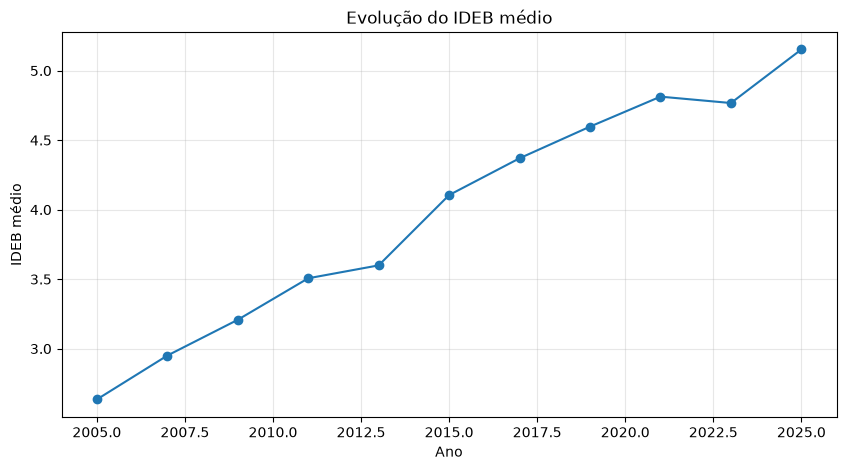

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(ideb_por_ano["ano"], ideb_por_ano["mean"], marker="o")
plt.xlabel("Ano")
plt.ylabel("IDEB médio")
plt.title("Evolução do IDEB médio")
plt.grid(alpha=0.3)
plt.show()


## 19. Distribuição geral do IDEB


In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(ideb["ideb"].dropna(), bins=30, edgecolor="black")
plt.xlabel("IDEB")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição do IDEB")
plt.show()


# Cruzamento entre Censo Escolar e IDEB


## 20. Identificação dos anos comuns


In [31]:
anos_comuns = sorted(
    set(censo["ano"].unique()).intersection(
        set(ideb["ano"].unique())
    )
)

print("Anos comuns:")
print(anos_comuns)


Anos comuns:
[np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021), np.int64(2023)]


## 21. Seleção dos anos comuns


In [32]:
censo_cruzamento = censo[
    censo["ano"].isin(anos_comuns)
].copy()

ideb_cruzamento = ideb[
    ideb["ano"].isin(anos_comuns)
].copy()

print("Censo:", censo_cruzamento.shape)
print("IDEB:", ideb_cruzamento.shape)


Censo: (780070, 50)
IDEB: (45234, 14)


## 22. Validação da chave


In [33]:
print(
    "Duplicidades da chave ano + id_escola no Censo:",
    censo_cruzamento.duplicated(["ano", "id_escola"]).sum()
)


Duplicidades da chave ano + id_escola no Censo: 0


## 23. Integração entre Censo Escolar e IDEB


In [34]:
dados = ideb_cruzamento.merge(
    censo_cruzamento,
    on=["ano", "id_escola"],
    how="left",
    validate="many_to_one",
    indicator=True,
    suffixes=("_ideb", "_censo")
)

print(dados.shape)


(45234, 63)


## 24. Qualidade do cruzamento


In [35]:
correspondencia = (
    dados["_merge"]
    .value_counts()
    .rename_axis("resultado")
    .reset_index(name="registros")
)

display(correspondencia)

percentual_correspondencia = (
    (dados["_merge"] == "both").mean() * 100
)

print(f"Correspondência entre IDEB e Censo: {percentual_correspondencia:.2f}%")


,resultado,registros
0,both,45234
1,left_only,0
2,right_only,0


Correspondência entre IDEB e Censo: 100.00%


## 25. Correspondência por ano


In [36]:
cruzamento_por_ano = (
    dados
    .groupby("ano")
    .agg(
        registros_ideb=("id_escola", "size"),
        escolas_distintas=("id_escola", "nunique"),
        encontrados=("_merge", lambda x: (x == "both").sum())
    )
    .reset_index()
)

cruzamento_por_ano["percentual_encontrado"] = (
    cruzamento_por_ano["encontrados"] /
    cruzamento_por_ano["registros_ideb"] * 100
)

display(cruzamento_por_ano)


,ano,registros_ideb,escolas_distintas,encontrados,percentual_encontrado
0,2007,4243,4000,4243,100.00
1,2009,5487,5233,5487,100.00
2,2011,5035,4811,5035,100.00
3,2013,4736,4519,4736,100.00
4,2015,4531,4329,4531,100.00
5,2017,5403,5187,5403,100.00
6,2019,5718,5453,5718,100.00
7,2021,4370,4210,4370,100.00
8,2023,5711,5454,5711,100.00


## 26. Dimensão final do conjunto integrado


In [37]:
print(f"Observações escola-etapa-ano: {len(dados):,}")

escola_ano = (
    dados[["ano", "id_escola"]]
    .drop_duplicates()
    .shape[0]
)

print(f"Combinações únicas escola-ano: {escola_ano:,}")


Observações escola-etapa-ano: 45,234
Combinações únicas escola-ano: 43,196


## 27. Estatísticas do IDEB após o cruzamento


In [38]:
dados["ideb"].describe()


count   45234.00
mean        4.01
std         1.21
min         0.30
25%         3.20
50%         3.90
75%         4.70
max        10.00
Name: ideb, dtype: float64

## 28. IDEB por ano após o cruzamento


In [39]:
ideb_cruzado_ano = (
    dados
    .groupby("ano")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(ideb_cruzado_ano)


,ano,count,mean,median,std
0,2007,4243,2.95,2.90,0.78
1,2009,5487,3.21,3.20,0.84
2,2011,5035,3.51,3.50,0.91
3,2013,4736,3.60,3.60,0.96
4,2015,4531,4.11,4.00,1.07
5,2017,5403,4.37,4.30,1.12
6,2019,5718,4.60,4.50,1.13
7,2021,4370,4.81,4.70,1.02
8,2023,5711,4.77,4.60,1.16


## 29. IDEB por etapa após o cruzamento


In [40]:
ideb_cruzado_etapa = (
    dados
    .groupby("anos_escolares")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(ideb_cruzado_etapa)


,anos_escolares,count,mean,median,std
0,finais (6-9),18148,3.63,3.60,1.08
1,iniciais (1-5),24390,4.31,4.20,1.24
2,todos (1-4),2696,3.96,3.90,0.86


## 30. IDEB por rede administrativa


In [41]:
ideb_rede = (
    dados
    .groupby("rede")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(ideb_rede)


,count,mean,median,std
rede,,,,
Privada,51,5.52,5.50,0.89
Federal,58,5.24,5.00,1.18
Municipal,35397,4.13,4.00,1.22
Estadual,9728,3.58,3.60,1.01


## 31. IDEB segundo localização da escola


In [42]:
ideb_localizacao = (
    dados
    .groupby("tipo_localizacao")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(ideb_localizacao)


,count,mean,median,std
tipo_localizacao,,,,
Rural,14414,4.05,3.90,1.24
Urbana,30820,4.00,3.90,1.19


## 32. Características de infraestrutura


In [43]:
variaveis_infraestrutura = [
    "agua_potavel",
    "agua_rede_publica",
    "energia_rede_publica",
    "esgoto_rede_publica",
    "lixo_servico_coleta",
    "area_verde",
    "banheiro_chuveiro",
    "biblioteca",
    "cozinha",
    "laboratorio_ciencias",
    "laboratorio_informatica",
    "quadra_esportes",
    "refeitorio",
    "sala_leitura",
    "desktop_aluno",
    "internet_alunos"
]

percentuais = []

for coluna in variaveis_infraestrutura:
    if coluna in dados.columns:
        serie = dados[coluna].dropna()
        percentual = serie.mean() * 100 if len(serie) > 0 else np.nan

        percentuais.append({
            "variavel": coluna,
            "percentual_presenca": percentual,
            "registros_validos": len(serie)
        })

infraestrutura_df = pd.DataFrame(percentuais)

display(
    infraestrutura_df.sort_values(
        "percentual_presenca",
        ascending=False
    )
)


,variavel,percentual_presenca,registros_validos
2,energia_rede_publica,99.78,45234
8,cozinha,97.55,45234
0,agua_potavel,95.25,15799
4,lixo_servico_coleta,85.17,45234
1,agua_rede_publica,80.67,45234
10,laboratorio_informatica,49.33,45234
14,desktop_aluno,46.74,15799
6,banheiro_chuveiro,43.07,30469
7,biblioteca,42.87,40991
15,internet_alunos,38.31,15799


## 33. IDEB médio segundo características de infraestrutura

Estas comparações são apenas descritivas e não devem ser interpretadas como relações causais.


In [44]:
variaveis_comparacao = [
    "biblioteca",
    "laboratorio_ciencias",
    "laboratorio_informatica",
    "quadra_esportes",
    "internet_alunos",
    "agua_potavel"
]

resultados = []

for coluna in variaveis_comparacao:
    if coluna in dados.columns:
        tabela = (
            dados
            .dropna(subset=[coluna])
            .groupby(coluna)["ideb"]
            .agg(["count", "mean", "median"])
            .reset_index()
        )

        tabela["variavel"] = coluna
        resultados.append(tabela)

if resultados:
    comparacao_infraestrutura = pd.concat(
        resultados,
        ignore_index=True
    )
    display(comparacao_infraestrutura)


,biblioteca,count,mean,median,variavel,laboratorio_ciencias,laboratorio_informatica,quadra_esportes,internet_alunos,agua_potavel
0,0.00,23417,4.14,4.10,biblioteca,NaN,NaN,NaN,NaN,NaN
1,1.00,17574,4.10,4.00,biblioteca,NaN,NaN,NaN,NaN,NaN
2,NaN,41374,4.02,3.90,laboratorio_ciencias,0.00,NaN,NaN,NaN,NaN
3,NaN,3860,3.97,4.00,laboratorio_ciencias,1.00,NaN,NaN,NaN,NaN
4,NaN,22918,4.03,3.90,laboratorio_informatica,NaN,0.00,NaN,NaN,NaN
5,NaN,22316,4.00,3.90,laboratorio_informatica,NaN,1.00,NaN,NaN,NaN
6,NaN,29474,3.94,3.80,quadra_esportes,NaN,NaN,0.00,NaN,NaN
7,NaN,15760,4.16,4.10,quadra_esportes,NaN,NaN,1.00,NaN,NaN
8,NaN,9747,4.70,4.60,internet_alunos,NaN,NaN,NaN,0.00,NaN
9,NaN,6052,4.75,4.60,internet_alunos,NaN,NaN,NaN,1.00,NaN


## 34. Construção de variáveis relacionadas às matrículas


In [45]:
dados["total_matriculas_sexo"] = (
    dados["quantidade_matricula_feminino"].fillna(0) +
    dados["quantidade_matricula_masculino"].fillna(0) +
    dados["quantidade_matricula_nao_declarada"].fillna(0)
)

dados["proporcao_feminino"] = np.where(
    dados["total_matriculas_sexo"] > 0,
    dados["quantidade_matricula_feminino"] /
    dados["total_matriculas_sexo"],
    np.nan
)


## 35. Composição racial das matrículas


In [47]:
colunas_raca = [
    "quantidade_matricula_branca",
    "quantidade_matricula_preta",
    "quantidade_matricula_parda",
    "quantidade_matricula_amarela",
    "quantidade_matricula_indigena"
]

dados["total_matriculas_raca"] = (
    dados[colunas_raca]
    .fillna(0)
    .sum(axis=1)
)

for coluna in colunas_raca:
    nome = coluna.replace(
        "quantidade_matricula_",
        "proporcao_"
    )

    dados[nome] = np.where(
        dados["total_matriculas_raca"] > 0,
        dados[coluna] / dados["total_matriculas_raca"],
        np.nan
    )


## 36. Correlações exploratórias

As correlações são utilizadas apenas como uma primeira medida de associação linear. Correlação não implica causalidade.


In [49]:
variaveis_correlacao = [
    "ideb",
    "quantidade_sala_utilizada_climatizada",
    "quantidade_profissional_saude",
    "quantidade_profissional_nutricionista",
    "quantidade_profissional_psicologo",
    "quantidade_profissional_pedagogia",
    "total_matriculas_sexo",
    "proporcao_feminino"
]

variaveis_correlacao = [
    col for col in variaveis_correlacao
    if col in dados.columns
]

correlacao = (
    dados[variaveis_correlacao]
    .corr(numeric_only=True)
)

display(correlacao)


,ideb,quantidade_sala_utilizada_climatizada,quantidade_profissional_saude,quantidade_profissional_nutricionista,quantidade_profissional_psicologo,quantidade_profissional_pedagogia,total_matriculas_sexo,proporcao_feminino
ideb,1.00,0.09,0.03,0.01,0.05,0.03,-0.23,0.29
quantidade_sala_utilizada_climatizada,0.09,1.00,0.14,0.04,0.10,0.12,0.30,0.08
quantidade_profissional_saude,0.03,0.14,1.00,0.04,0.13,0.13,0.06,0.01
quantidade_profissional_nutricionista,0.01,0.04,0.04,1.00,0.38,0.06,-0.01,-0.00
quantidade_profissional_psicologo,0.05,0.10,0.13,0.38,1.00,0.12,0.08,-0.02
quantidade_profissional_pedagogia,0.03,0.12,0.13,0.06,0.12,1.00,0.21,0.02
total_matriculas_sexo,-0.23,0.30,0.06,-0.01,0.08,0.21,1.00,-0.24
proporcao_feminino,0.29,0.08,0.01,-0.00,-0.02,0.02,-0.24,1.00


# Síntese da análise exploratória

A análise mostrou que as bases do Censo Escolar e do IDEB apresentam boa compatibilidade para integração por meio das variáveis `ano` e `id_escola`.

O Censo Escolar possui cobertura entre 2007 e 2024, enquanto o IDEB apresenta registros entre 2005 e 2025. Os anos em comum utilizados no cruzamento são 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021 e 2023.

Não foram encontradas duplicidades para a combinação `ano + id_escola` no Censo Escolar. No IDEB, uma mesma escola pode possuir diferentes registros no mesmo ano devido às diferentes etapas de ensino, sendo necessária a utilização da variável `anos_escolares` para identificar unicamente cada observação.

Também foi constatado que diversas variáveis do Censo apresentam elevada quantidade de valores ausentes devido principalmente a mudanças na disponibilidade dos atributos ao longo do tempo. Dessa forma, a seleção das variáveis utilizadas nas análises posteriores deverá considerar sua cobertura temporal.

O cruzamento entre as bases apresentou elevada correspondência entre os registros do IDEB e do Censo Escolar nos anos comuns. As análises posteriores deverão controlar fatores como ano, etapa de ensino, rede administrativa, localização e tamanho da escola antes de avaliar a associação entre características escolares e desempenho no IDEB.
